## Import Library

In [5]:
import pandas as pd 
import matplotlib.pyplot as plt
import math 
import numpy as np

## Import Dataset

In [ ]:
data_fraud = pd.read_csv("PS_20174392719_1491204439457_log.csv")
data_fraud.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## EDA (Exploratory Data Analysis)

### 1. View Dataset Information

In [7]:
data_fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


### 2. Viewing the Amount of Empty Data

In [8]:
data_fraud.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

### 3. Viewing the Histogram

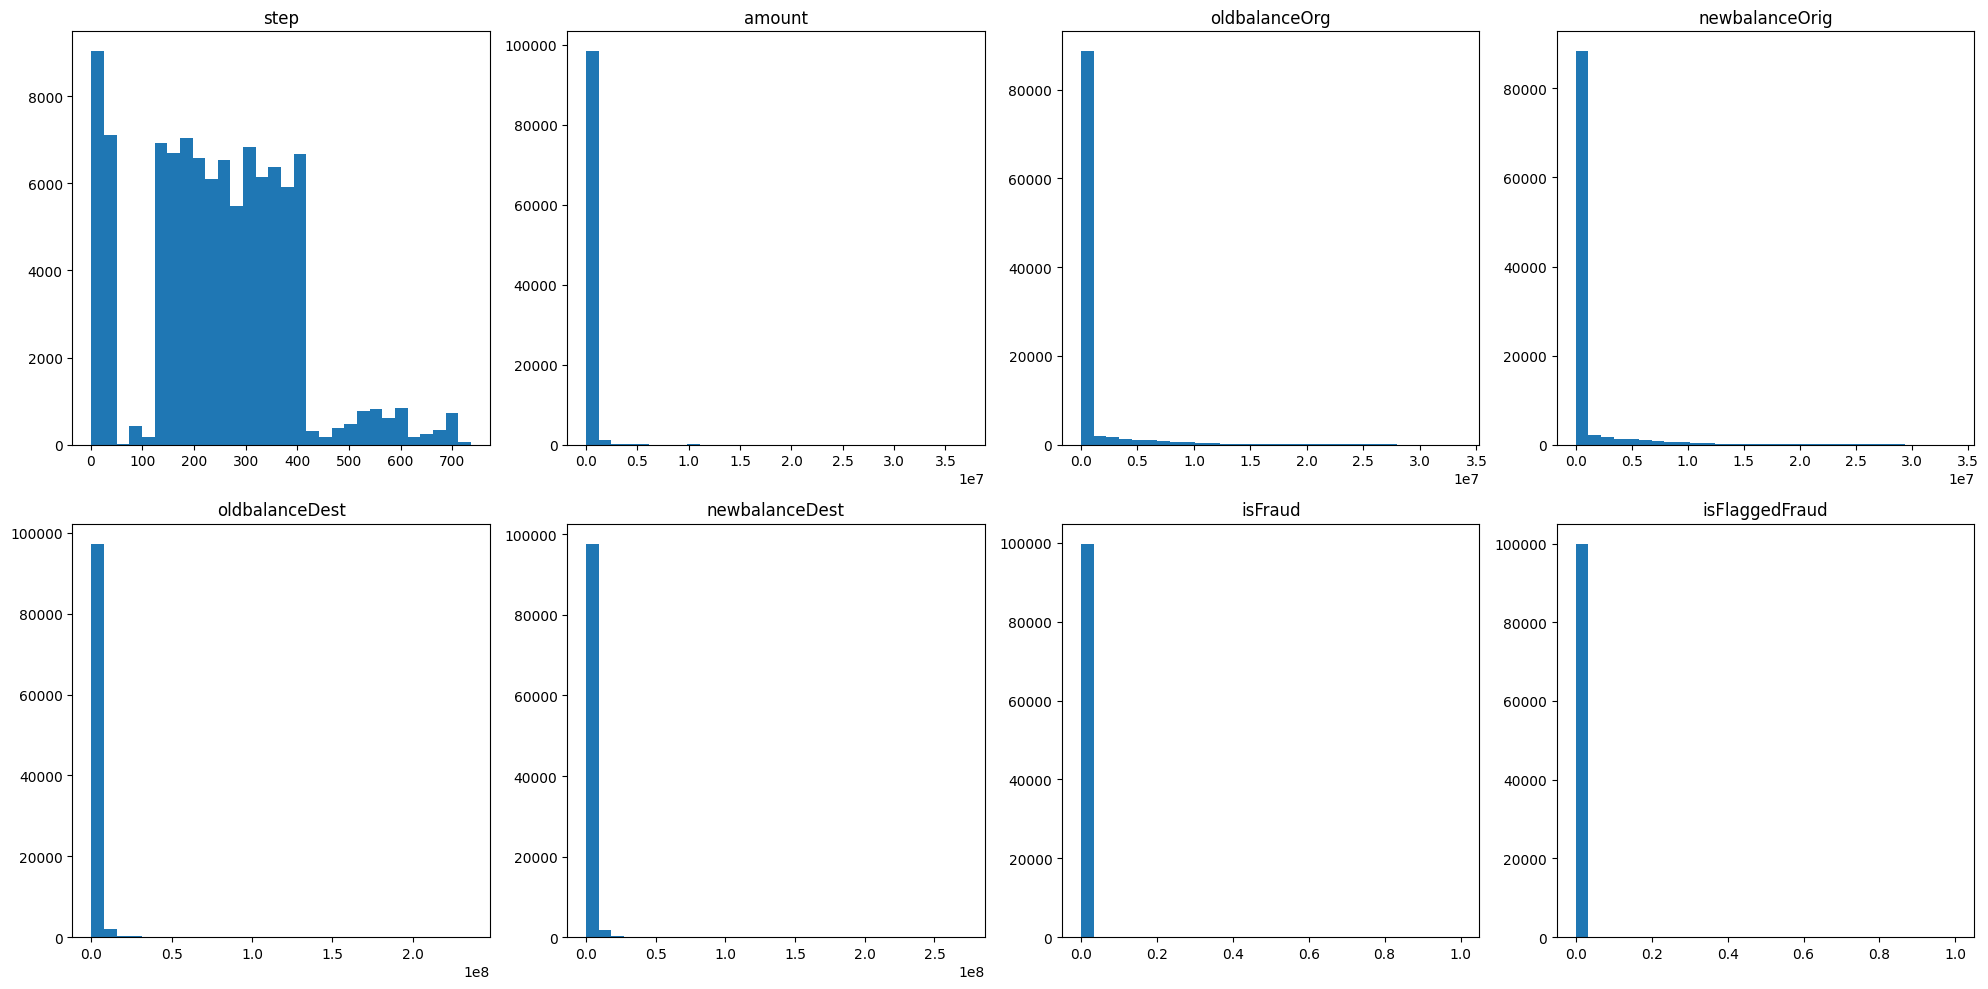

In [9]:
data_sample = data_fraud.sample(100_000, random_state=42)

num_cols = data_sample.select_dtypes(include='number').columns
n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(data_sample[col], bins=30)
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Preprocessing

### 1. Removing Unused Variables

In [10]:
data_fraud = data_fraud.drop(columns=['step','nameOrig', 'nameDest', 'isFlaggedFraud'])
data_fraud.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


### 2. Dividing Data Into Training Data and Test Data

In [11]:
X = data_fraud.drop(columns=['isFraud'])
y = data_fraud['isFraud']

### 3. Seperate Payment Types

In [12]:
X = pd.get_dummies(X, columns=['type'], drop_first=True)

### 4. Train Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

### 5. Normalization

In [14]:
from sklearn.preprocessing import RobustScaler

num_cols = [
    'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest'
]

scaler = RobustScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

## Modelling

### 1. Random Forest

Akurasi: 0.9996259402573154
/nClassification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.98      0.73      0.83      1643

    accuracy                           1.00   1272524
   macro avg       0.99      0.86      0.92   1272524
weighted avg       1.00      1.00      1.00   1272524



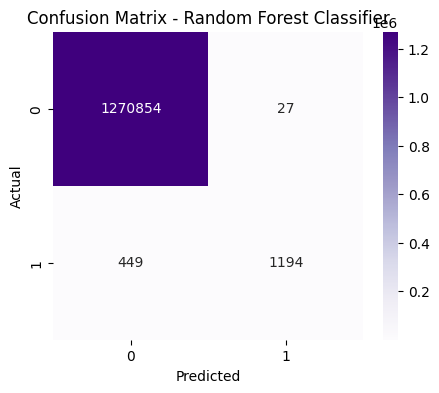

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

model_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_leaf=100,
    n_jobs=-1,
    random_state=42
)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred_rf))
print("/nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

### 2. XGBoost

Akurasi: 0.9934138766734458
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      1.00   1270881
       Fraud       0.16      1.00      0.28      1643

    accuracy                           0.99   1272524
   macro avg       0.58      1.00      0.64   1272524
weighted avg       1.00      0.99      1.00   1272524



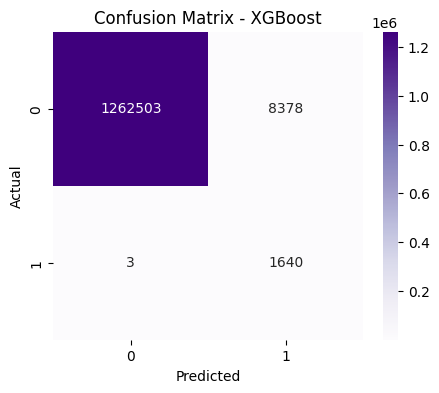

In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",   
    eval_metric="logloss",
    scale_pos_weight= (len(y_train) - y_train.sum()) / y_train.sum(),  
    n_jobs=-1,
    random_state=42
)

model_xgb.fit(X_train, y_train)

y_pred_xg = model_xgb.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred_xg))

print(classification_report(
    y_test,
    y_pred_xg,
    target_names=['Not Fraud', 'Fraud']
))

cm = confusion_matrix(y_test, y_pred_xg)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

### 3. Logistic Regression

c:\Users\Nicolaus Prima\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Akurasi: 0.9469864615520022
              precision    recall  f1-score   support

   Not Fraud       1.00      0.95      0.97   1270881
       Fraud       0.02      0.94      0.04      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.95      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



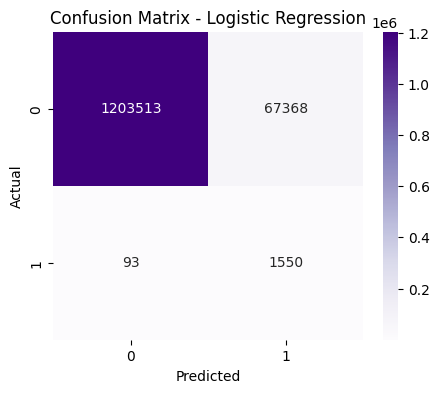

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   # penting untuk imbalance
    n_jobs=-1,
    random_state=42
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
print("Akurasi:", accuracy_score(y_test, y_pred_log))

print(classification_report(
    y_test, y_pred_log,
    target_names=['Not Fraud', 'Fraud']
))

cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 4. LightGBM

[LightGBM] [Info] Number of positive: 6570, number of negative: 5083526
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015885 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1283
[LightGBM] [Info] Number of data points in the train set: 5090096, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001291 -> initscore=-6.651247
[LightGBM] [Info] Start training from score -6.651247
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further spli

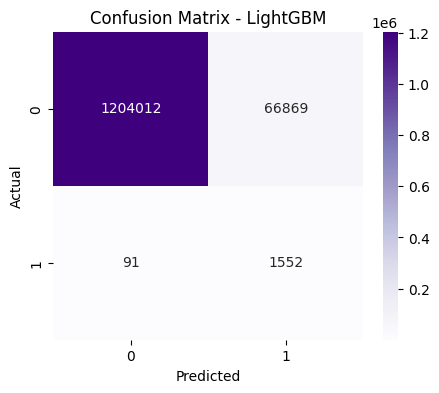

In [31]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# hitung imbalance ratio
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective='binary',
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
print("Akurasi:", accuracy_score(y_test, y_pred_lgb))

print(classification_report(
    y_test, y_pred_lgb,
    target_names=['Not Fraud', 'Fraud']
))

cm = confusion_matrix(y_test, y_pred_lgb)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Evaluation Model

### 1. ROC - AUC

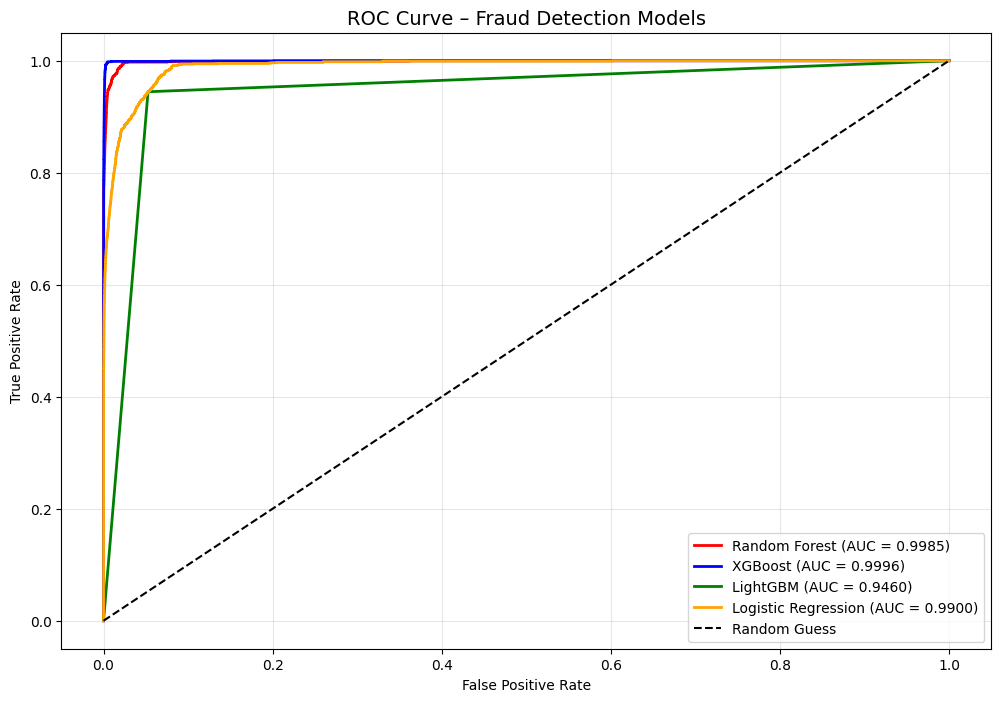

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

def plot_roc(y_true, y_prob, label, color):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color,
             label=f"{label} (AUC = {roc_auc:.4f})")

# ambil probabilitas FRAUD (kolom index 1)
plot_roc(y_test, model_rf.predict_proba(X_test)[:, 1], "Random Forest", "red")
plot_roc(y_test, model_xgb.predict_proba(X_test)[:, 1], "XGBoost", "blue")
plot_roc(y_test, lgb_model.predict_proba(X_test)[:, 1], "LightGBM", "green")
plot_roc(y_test, log_model.predict_proba(X_test)[:, 1], "Logistic Regression", "orange")

# baseline
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.title("ROC Curve – Fraud Detection Models", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


### 2. Feature Importance

#### a. Random Forest

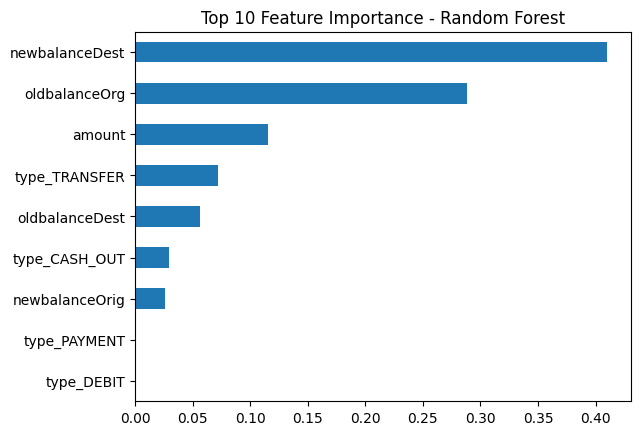

In [20]:
importances = model_rf.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

feat_imp.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.show()

#### b. XGBoost

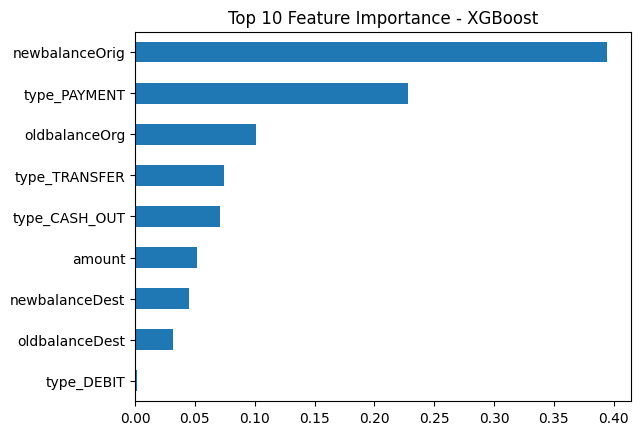

In [21]:
importances = model_xgb.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

feat_imp.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importance - XGBoost')
plt.gca().invert_yaxis()
plt.show()

#### c. LightGBM

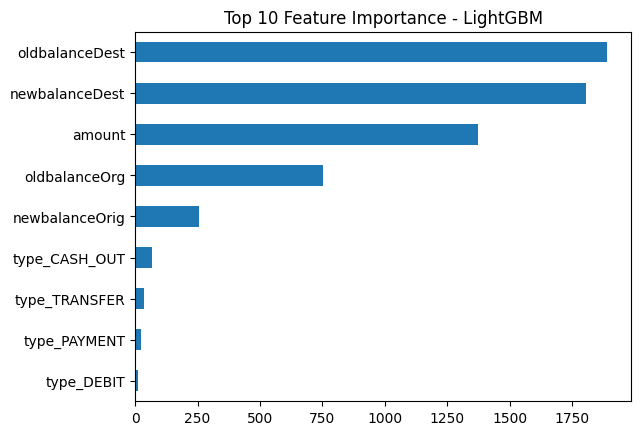

In [22]:
importances = lgb_model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

feat_imp.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importance - LightGBM')
plt.gca().invert_yaxis()
plt.show()

#### d. Logistic Regression

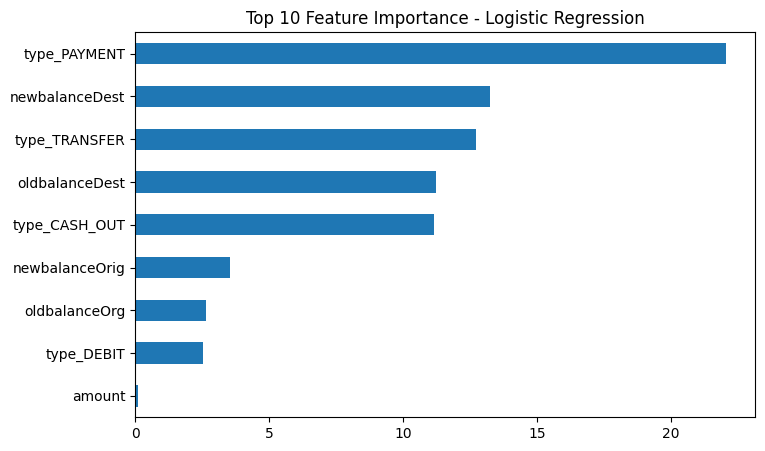

In [23]:
coef = log_model.coef_[0]

feat_imp = pd.Series(np.abs(coef), index=X_train.columns)\
              .sort_values(ascending=False)

feat_imp.head(10).plot(kind='barh', figsize=(8,5))
plt.title('Top 10 Feature Importance - Logistic Regression')
plt.gca().invert_yaxis()
plt.show()


### 3. Overal Score

#### a. Random Forest

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
recall_rf    = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf        = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print("Precision (weighted):", precision_rf)
print("Recall (weighted):   ", recall_rf)
print("F1-score (weighted): ", f1_rf)

Precision (weighted): 0.9986626747954251
Recall (weighted):    0.9473801672895756
F1-score (weighted):  0.9717462764605357


#### b. XGBoost

In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_xg = precision_score(y_test, y_pred_xg, average='weighted', zero_division=0)
recall_xg    = recall_score(y_test, y_pred_xg, average='weighted', zero_division=0)
f1_xg        = f1_score(y_test, y_pred_xg, average='weighted', zero_division=0)

print("Precision (weighted):", precision_xg)
print("Recall (weighted):   ", recall_xg)
print("F1-score (weighted): ", f1_xg)

Precision (weighted): 0.998917857704028
Recall (weighted):    0.9934138766734458
F1-score (weighted):  0.995768086900242


### c. Logistic Regression

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_log = precision_score(y_test, y_pred_log, average='weighted', zero_division=0)
recall_log    = recall_score(y_test, y_pred_log, average='weighted', zero_division=0)
f1_log        = f1_score(y_test, y_pred_log, average='weighted', zero_division=0)

print("Precision (weighted):", precision_log)
print("Recall (weighted):   ", recall_log)
print("F1-score (weighted): ", f1_log)

Precision (weighted): 0.998660735430464
Recall (weighted):    0.9469864615520022
F1-score (weighted):  0.9715381686608865


#### d. LightGBM

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_ = precision_score(y_test, y_pred_lgb, average='weighted', zero_division=0)
recall_    = recall_score(y_test, y_pred_lgb, average='weighted', zero_division=0)
f1_        = f1_score(y_test, y_pred_lgb, average='weighted', zero_division=0)

print("Precision (weighted):", precision_)
print("Recall (weighted):   ", recall_)
print("F1-score (weighted): ", f1_)

Precision (weighted): 0.9986626747954251
Recall (weighted):    0.9473801672895756
F1-score (weighted):  0.9717462764605357
